# Establish a classical baseline
We use xgboost on the given datasets to classifiy tornadoes. We show the results for both the binary (weak and strong) classification and the classification into specific EF categories, called multiclass.

## Binary Classification with XGBoost

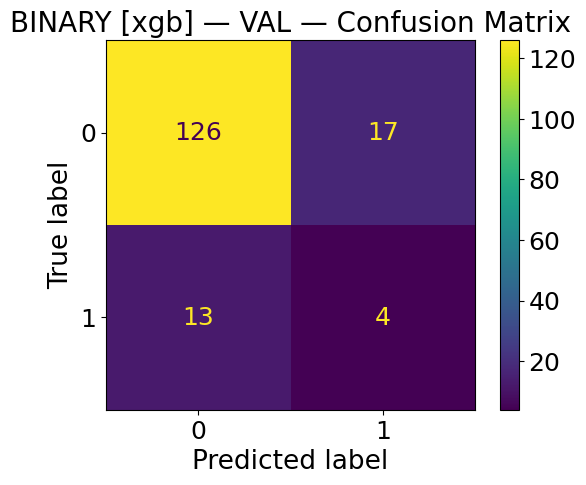

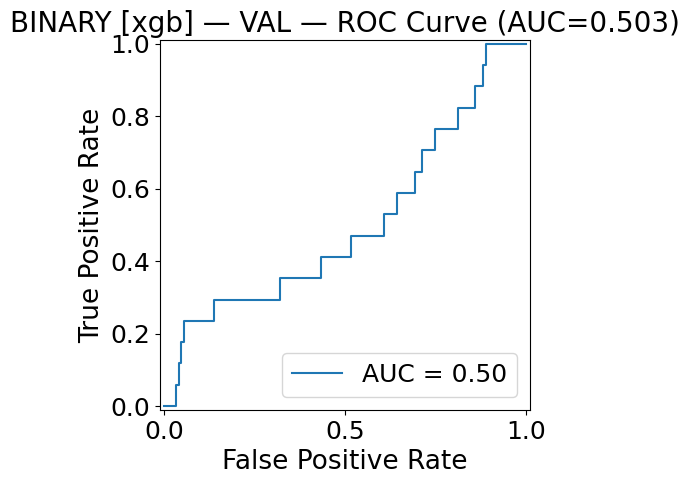

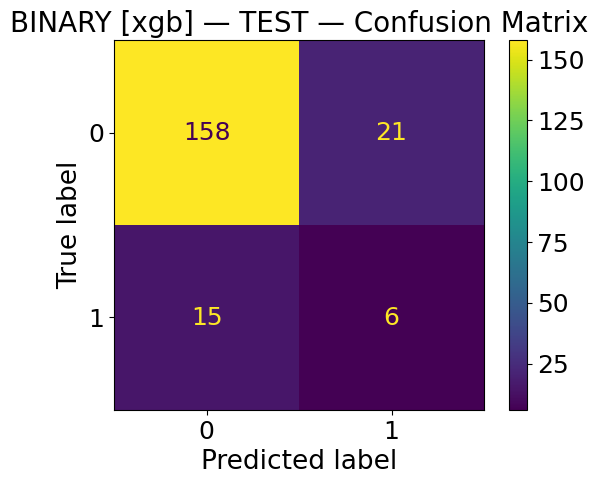

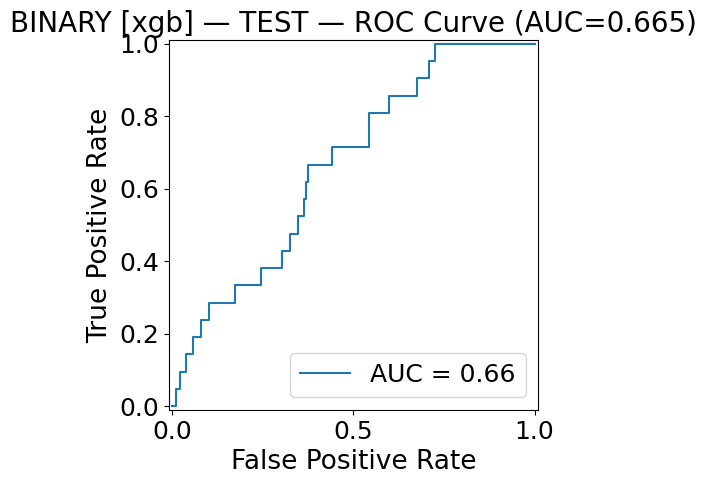

('xgb', 0.5034965034965035, 0.6648044692737429)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    RocCurveDisplay,
)

from tornadoq.benchmark_models import get_binary_estimators
from tornadoq.preprocess import PreprocessConfig, split_xy, build_preprocessor
from tornadoq.evaluate_classical_benchmarks import cv_evaluate_binary
from tornadoq.io import load_train_val_test
from tornadoq.config import CVConfig


# -------------------------
# Config
# -------------------------
models_to_test = ["xgb"] # choose from any number of "logreg", "rf" "gb" and "xgb". Note RAM issues may surface.


TRAIN = "../Data/original/2025-Quantathon-Tornado-Q-training_data-640-examples.xlsx"
VAL   = "../Data/original/2025-Quantum-Tornado-validation_data-160-examples.xlsx"
TEST  = "../Data/original/2025-Quantum-Tornado-Q-test_data-200-examples.xlsx"

cv_cfg = CVConfig(folds=5, shuffle=True, random_state=42, repeats=1)
cv_metric = "cv_roc_auc_mean"   # change if your cv table uses a different column name


# -------------------------
# Load + split
# -------------------------
df_tr, df_va, df_te = load_train_val_test(TRAIN, VAL, TEST)

X_tr, X_va, y_tr, y_va = split_xy(df_tr, df_va, target="ef_binary")
_,   X_te, _,   y_te   = split_xy(df_tr, df_te, target="ef_binary")  # anchors test columns to train columns


# -------------------------
# Build models
# -------------------------
pre = build_preprocessor(X_tr, PreprocessConfig(scaler="minmax"))
models = get_binary_estimators(pre, use_smote=True, models_to_test=models_to_test)


# -------------------------
# CV select best (TRAIN only)
# -------------------------
cv_tbl = cv_evaluate_binary(models, X_tr, y_tr, cv_cfg)
if cv_metric not in cv_tbl.columns:
    raise KeyError(f"'{cv_metric}' not in CV table columns: {list(cv_tbl.columns)}")

best_name = cv_tbl.sort_values(cv_metric, ascending=False).index[0]
best_model = models[best_name]


# -------------------------
# Helper plotting
# -------------------------
def _binary_eval_and_plots(model, X_fit, y_fit, X_eval, y_eval, title_prefix: str):
    """
    Fits `model` on (X_fit,y_fit), then evaluates on (X_eval,y_eval),
    and plots Confusion Matrix + ROC curve. Returns dict with predictions + auc.
    """
    m = clone(model)
    m.fit(X_fit, y_fit)

    # predictions
    y_pred = m.predict(X_eval)

    # proba for ROC/AUC
    if hasattr(m, "predict_proba"):
        y_score = m.predict_proba(X_eval)[:, 1]
    else:
        # fallback: decision_function (some models)
        y_score = m.decision_function(X_eval)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_eval, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(values_format="d")
    plt.title(f"{title_prefix} — Confusion Matrix")
    plt.show()

    # --- ROC / AUC ---
    fpr, tpr, _ = roc_curve(y_eval, y_score)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
    plt.title(f"{title_prefix} — ROC Curve (AUC={roc_auc:.3f})")
    plt.show()

    return {"y_pred": y_pred, "y_score": y_score, "auc": roc_auc}


# -------------------------
# VAL (fit TRAIN → eval VAL)
# -------------------------
val_out = _binary_eval_and_plots(
    best_model,
    X_tr, y_tr,
    X_va, y_va,
    title_prefix=f"BINARY [{best_name}] — VAL"
)

# -------------------------
# TEST (fit TRAIN+VAL → eval TEST)
# -------------------------
X_trva = pd.concat([X_tr, X_va], axis=0, ignore_index=True)
y_trva = pd.concat([y_tr, y_va], axis=0, ignore_index=True)

test_out = _binary_eval_and_plots(
    best_model,
    X_trva, y_trva,
    X_te, y_te,
    title_prefix=f"BINARY [{best_name}] — TEST"
)

best_name, val_out["auc"], test_out["auc"]


# Multiclass Classification with XGBoost

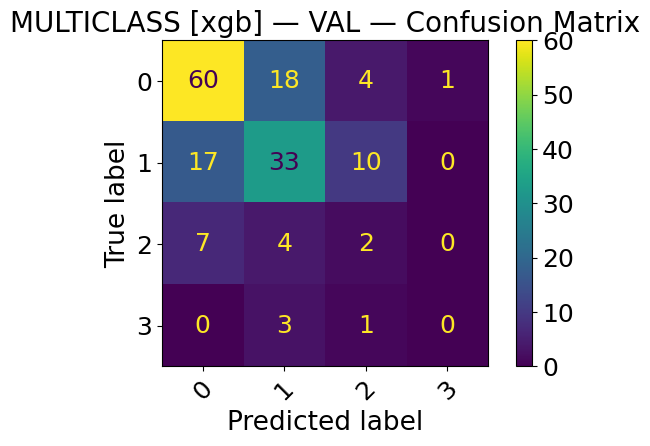

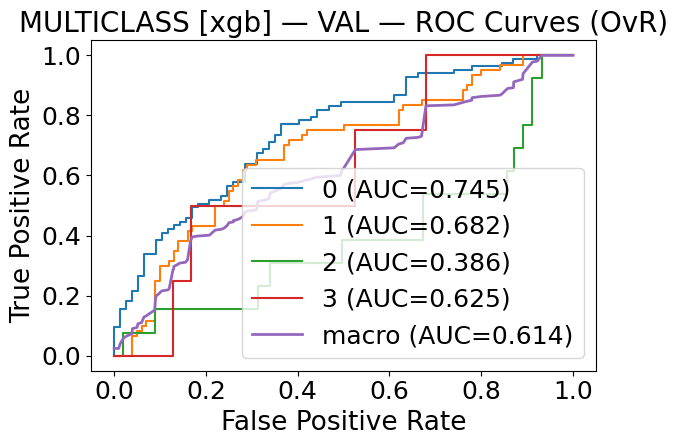

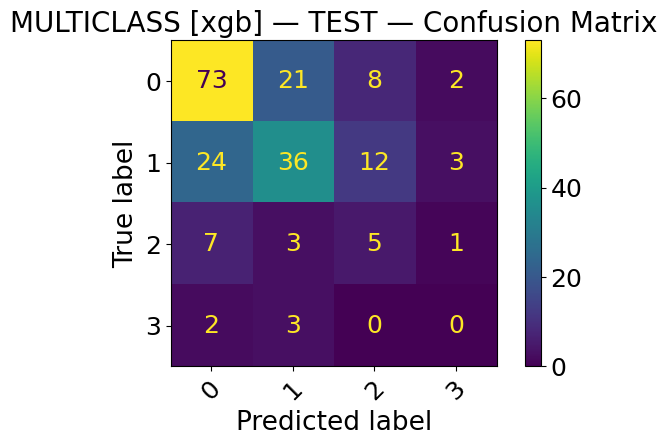

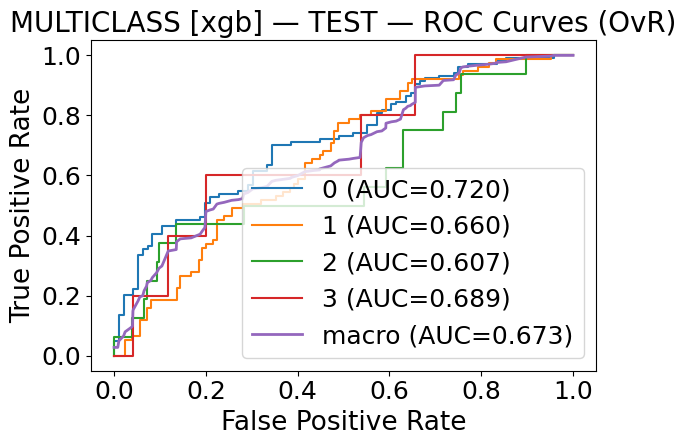

('xgb', 0.6143220594188753, 0.672687168294243)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

from tornadoq.benchmark_models import get_multiclass_estimators
from tornadoq.preprocess import PreprocessConfig, split_xy, build_preprocessor
from tornadoq.evaluate_classical_benchmarks import cv_evaluate_multiclass
from tornadoq.io import load_train_val_test
from tornadoq.config import CVConfig

cv_cfg = CVConfig(folds=5, shuffle=True, random_state=42, repeats=1)
cv_metric = 'cv_acc_mean'

# -------------------------
# Load + split
# -------------------------
df_tr, df_va, df_te = load_train_val_test(TRAIN, VAL, TEST)

X_tr, X_va, y_tr, y_va = split_xy(df_tr, df_va, target="ef_class")
_,   X_te, _,   y_te   = split_xy(df_tr, df_te, target="ef_class")


# -------------------------
# Encode labels consistently (important for multiclass ROC)
# -------------------------
le = LabelEncoder()
y_tr_enc = le.fit_transform(y_tr)
y_va_enc = le.transform(y_va)
y_te_enc = le.transform(y_te)
class_names = list(le.classes_)
n_classes = len(class_names)


# -------------------------
# Build models
# -------------------------
pre = build_preprocessor(X_tr, PreprocessConfig(scaler="minmax"))
models = get_multiclass_estimators(preprocessor=pre, use_smote=True, models_to_test=models_to_test)


# -------------------------
# CV select best (TRAIN only)
# -------------------------
cv_tbl = cv_evaluate_multiclass(models, X_tr, y_tr_enc, cv_cfg)
if cv_metric not in cv_tbl.columns:
    raise KeyError(f"'{cv_metric}' not in CV table columns: {list(cv_tbl.columns)}")

best_name = cv_tbl.sort_values(cv_metric, ascending=False).index[0]
best_model = models[best_name]


# -------------------------
# Helper plotting
# -------------------------
def _multiclass_eval_and_plots(model, X_fit, y_fit, X_eval, y_eval, title_prefix: str, class_names: list[str]):
    """
    Fits `model` on (X_fit,y_fit), evaluates on (X_eval,y_eval),
    plots Confusion Matrix + One-vs-Rest ROC curves + macro-average AUC.
    """
    m = clone(model)
    m.fit(X_fit, y_fit)

    y_pred = m.predict(X_eval)

    # proba for ROC/AUC
    if hasattr(m, "predict_proba"):
        y_score = m.predict_proba(X_eval)  # shape: (n_samples, n_classes)
    else:
        # some models have decision_function; if so, use it
        y_score = m.decision_function(X_eval)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_eval, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title(f"{title_prefix} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # --- Multiclass ROC (OvR) ---
    # binarize labels for ROC computation
    y_eval_bin = label_binarize(y_eval, classes=np.arange(len(class_names)))

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_eval_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # macro-average AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(class_names)

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # plot
    plt.figure()
    for i, name in enumerate(class_names):
        plt.plot(fpr[i], tpr[i], label=f"{name} (AUC={roc_auc[i]:.3f})")
    plt.plot(fpr["macro"], tpr["macro"], label=f"macro (AUC={roc_auc['macro']:.3f})", linewidth=2)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} — ROC Curves (OvR)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"y_pred": y_pred, "y_score": y_score, "auc_macro": roc_auc["macro"], "auc_per_class": roc_auc}


# -------------------------
# VAL (fit TRAIN → eval VAL)
# -------------------------
val_out = _multiclass_eval_and_plots(
    best_model,
    X_tr, y_tr_enc,
    X_va, y_va_enc,
    title_prefix=f"MULTICLASS [{best_name}] — VAL",
    class_names=class_names,
)

# -------------------------
# TEST (fit TRAIN+VAL → eval TEST)
# -------------------------
X_trva = pd.concat([X_tr, X_va], axis=0, ignore_index=True)
y_trva_enc = np.concatenate([y_tr_enc, y_va_enc], axis=0)

test_out = _multiclass_eval_and_plots(
    best_model,
    X_trva, y_trva_enc,
    X_te, y_te_enc,
    title_prefix=f"MULTICLASS [{best_name}] — TEST",
    class_names=class_names,
)

best_name, val_out["auc_macro"], test_out["auc_macro"]


# Hybrid Pipeline
## 1. Generate classical shadows

In [15]:
from torch.utils.data import DataLoader
from tornadoq.preprocessing import ClassificationDataset, Preprocess, DataMaker

withShadows = False

# Data paths
TRAIN_FILE = "../Data/original/2025-Quantathon-Tornado-Q-training_data-640-examples.xlsx"
TEST_FILE = "../Data/original/2025-Quantum-Tornado-Q-test_data-200-examples.xlsx"
VALIDATION_FILE = '../Data/original/2025-Quantum-Tornado-validation_data-160-examples.xlsx'

# Create pandas dataframes
df_train, df_test, df_val = DataMaker(TRAIN_FILE, TEST_FILE, VALIDATION_FILE, withShadows = withShadows, output_filename="original_shadow_enhanced.csv")

print()
print(df_train.columns.tolist())

classifier = 'binary'

# Preprocessing
X_train, y_train, X_test, y_test, X_val, y_val = Preprocess(df_train, df_test, df_val, balance = 'smote', classes = classifier)

print()
print(y_val)


train_data = ClassificationDataset(X_train, y_train)
validation_data = ClassificationDataset(X_val, y_val)
test_data = ClassificationDataset(X_test, y_test)

# Dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(validation_data, batch_size=64, shuffle=False, drop_last=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, drop_last=True)

print("\nNumber of training samples:", len(train_data))
print("Number of validation samples:", len(validation_data))
print("Number of test samples:", len(test_data))

✓ Combined data saved: 1000 rows, 10 columns

['cape', 'cin', 'dewpoint_2m', 'temp_2m', 'tcwv', 'surface_pressure', 'shear_0_1km', 'shear_0_3km', 'ef_class', 'ef_binary']

0      0
1      0
2      1
3      0
4      0
      ..
155    0
156    0
157    0
158    0
159    0
Name: ef_binary, Length: 160, dtype: int64

Number of training samples: 1142
Number of validation samples: 160
Number of test samples: 200


In [16]:
num_targets = 2 # ef_class and ef_binary are the targets
num_features = (len(df_train.columns)) - num_targets

## 2. Create Deep Neural Network Model

<class 'tornadoq.models.BinaryDNN'>
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
Epoch [1] had best val_metric
Epoch [1] had best val_Loss
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
Epoch [2] had best val_metric
Epoch [2] had best val_Loss
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Si

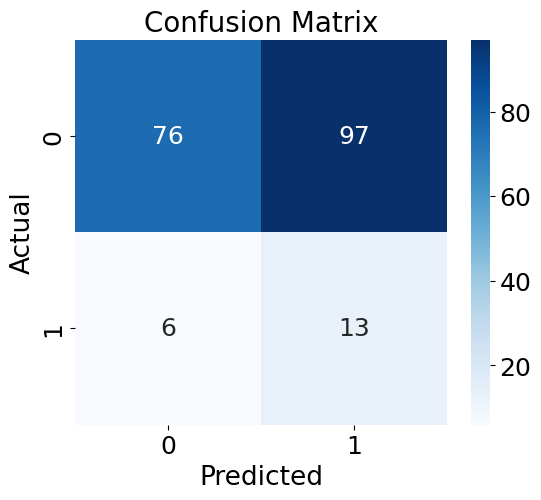

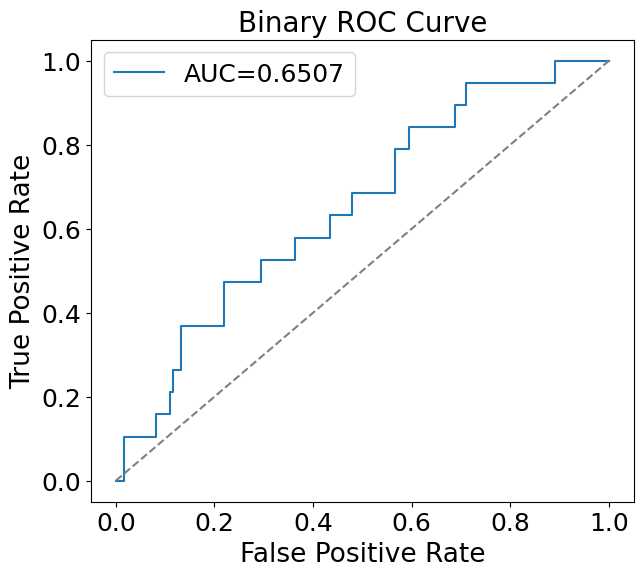

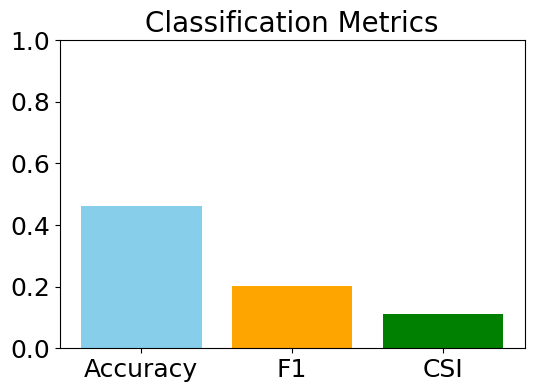

In [17]:
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_model, save

# Choose model and hyperparameters
model = "DNN"

n_epochs = 45
lr = .01
input_size = len(X_train.columns)
# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = num_features)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader, val_loader = val_loader, classifier = classifier)
eval_model(model = model, test_loader = test_loader, classifier = classifier, fontsize = 18)

# Training automatically saves the best performing model paramters
# Optionally, save the final model parameters
# save(model = model, save_path = None)
# Or load a previously trained model
# load(model = model, load_path = "")

# Quantum Machine Learning Pipeline
## 1. Use original dataset (no classical shadows)
Due to qpu limitations, we are unable to run a circuit for the dataset with shadows

In [7]:
from torch.utils.data import DataLoader
from tornadoq.preprocessing import ClassificationDataset, Preprocess, DataMaker

withShadows = False

# Data paths
TRAIN_FILE = "../Data/original/2025-Quantathon-Tornado-Q-training_data-640-examples.xlsx"
TEST_FILE = "../Data/original/2025-Quantum-Tornado-Q-test_data-200-examples.xlsx"
VALIDATION_FILE = '../Data/original/2025-Quantum-Tornado-validation_data-160-examples.xlsx'

# Create pandas dataframes
df_train, df_test, df_val = DataMaker(TRAIN_FILE, TEST_FILE, VALIDATION_FILE, withShadows = withShadows, output_filename="original_shadow_enhanced.csv")

print()
print(df_train.columns.tolist())

classifier = 'binary'

# Preprocessing
X_train, y_train, X_test, y_test, X_val, y_val = Preprocess(df_train, df_test, df_val, balance = 'smote', classes = classifier)

print()
print(y_val)


train_data = ClassificationDataset(X_train, y_train)
validation_data = ClassificationDataset(X_val, y_val)
test_data = ClassificationDataset(X_test, y_test)

# Dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(validation_data, batch_size=64, shuffle=False, drop_last=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, drop_last=True)

print("\nNumber of training samples:", len(train_data))
print("Number of validation samples:", len(validation_data))
print("Number of test samples:", len(test_data))

✓ Combined data saved: 1000 rows, 10 columns

['cape', 'cin', 'dewpoint_2m', 'temp_2m', 'tcwv', 'surface_pressure', 'shear_0_1km', 'shear_0_3km', 'ef_class', 'ef_binary']

0      0
1      0
2      1
3      0
4      0
      ..
155    0
156    0
157    0
158    0
159    0
Name: ef_binary, Length: 160, dtype: int64

Number of training samples: 1142
Number of validation samples: 160
Number of test samples: 200


## 2. Instantiate StronglyEntangling Ansatz

<class 'tornadoq.models.BinaryPQC'>
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
Epoch [1] had best val_metric
Epoch [1] had best val_Loss
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
Epoch [2] had best val_metric
Epoch [2] had best val_Loss
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Si

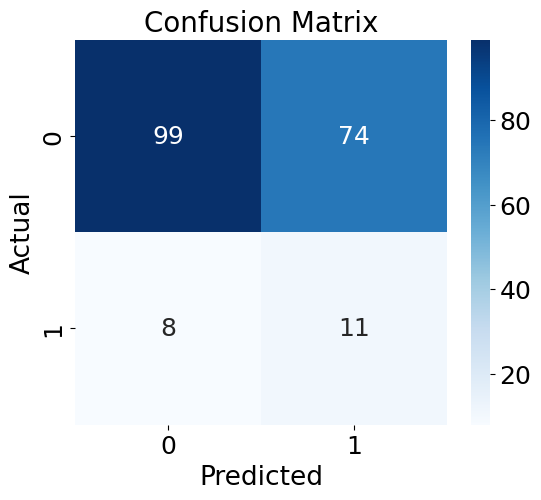

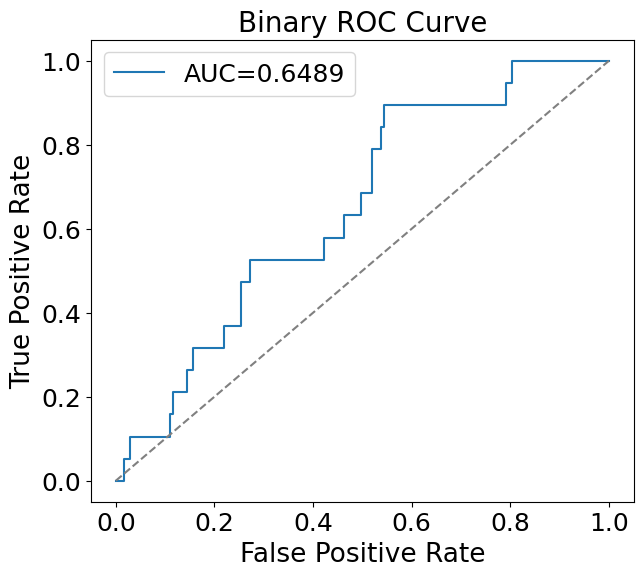

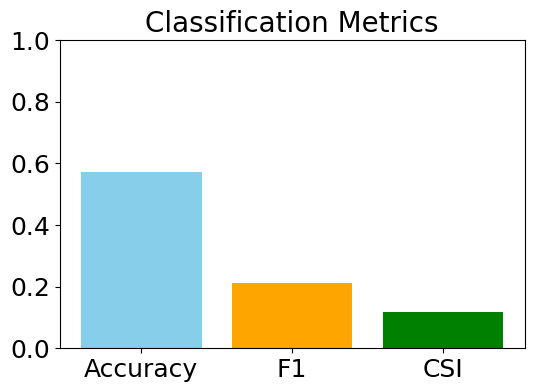

In [8]:
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_model, save
from torch.utils.data import DataLoader
from tornadoq.preprocessing import ClassificationDataset, Preprocess, DataMaker

# StronglyEntangling and RandomLayers need me to load the original dataset 

# Choose model and hyperparameters
# model = "DNN"
model = "StronglyEntangling"
# model = "RandomLayer"
n_epochs = 45
lr = .01


df_train, df_test, df_val = DataMaker(TRAIN_FILE, TEST_FILE, VALIDATION_FILE, withShadows = None, output_filename=None)


# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = 8)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader, val_loader = val_loader, classifier = classifier)
eval_model(model = model, test_loader = test_loader, classifier = classifier, fontsize = 18)

# Training automatically saves the best performing model paramters
# Optionally, save the final model parameters
# save(model = model, save_path = None)
# Or load a previously trained model
# load(model = model, load_path = "")

## 3. Instantiate RandomLayers ansatz

<class 'tornadoq.models.BinaryPQC'>
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
Epoch [1] had best val_metric
Epoch [1] had best val_Loss
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.Size([64, 1])
torch.

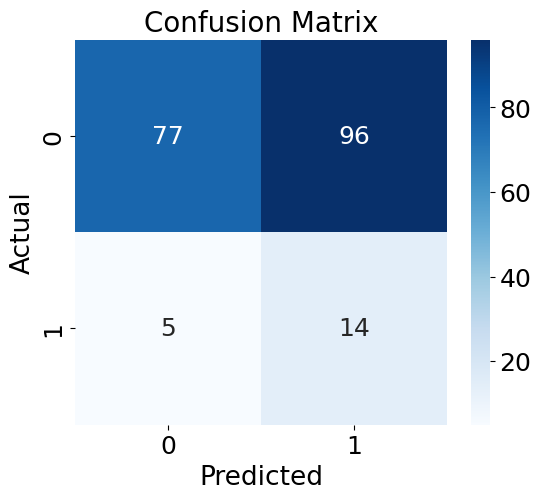

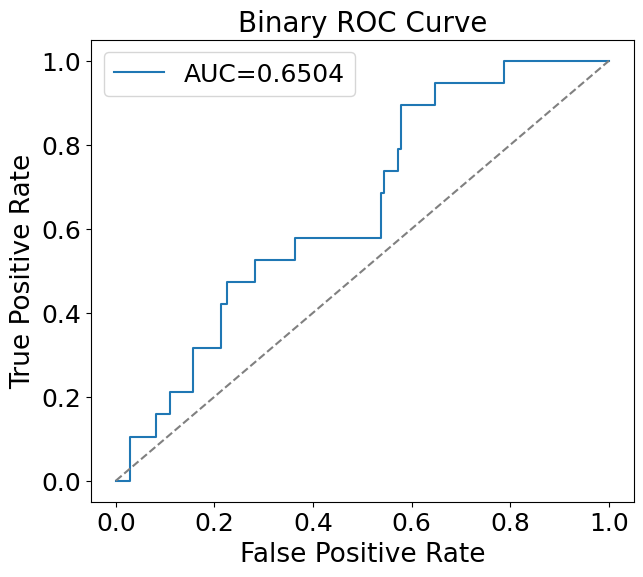

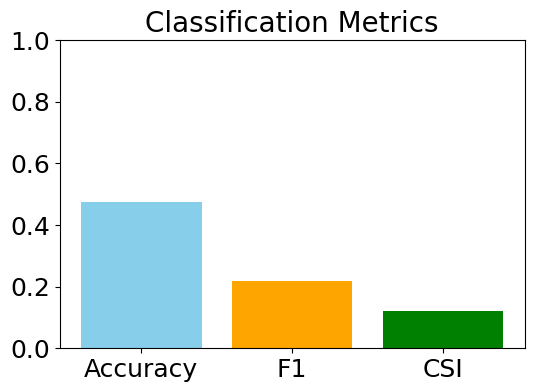

In [9]:
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_model, save

# Choose model and hyperparameters
# model = "DNN"
# model = "StronglyEntangling"
model = "RandomLayer"
n_epochs = 45
lr = .01

# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = 8)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader, val_loader = val_loader, classifier = classifier)
eval_model(model = model, test_loader = test_loader, classifier = classifier, fontsize = 18)

# Training automatically saves the best performing model paramters
# Optionally, save the final model parameters
# save(model = model, save_path = None)
# Or load a previously trained model
# load(model = model, load_path = "")

2.2.3
